# Magic Wand Project

The universal workflow of machine learning is as follows:
1. _Define the task_
2. _Develop a model_
3. _Deploy the model_

## Define The Task

The aim of this project is to develop an application that can detect harry potter wand movements. The project uses accelerometer data to predict which spell is being performed. The project utilises the following equipment:
1. An STM32F401RE
1. A MPU6050

## Developing A Model

In [1]:
# Importing the libraries
import os 
import shutil
import csv
import random
import math

import matplotlib.pyplot as plt
import scienceplots
import numpy as np
import pandas as pd
from sklearn.utils import shuffle
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input, Flatten
from tensorflow.keras.layers import Conv2D, GlobalAveragePooling1D, GlobalAveragePooling2D, MaxPooling2D

/Users/owaistalpur/Desktop/Embedded/magic_wand_project/.venv/lib/python3.13/site-packages/google/protobuf/runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
/Users/owaistalpur/Desktop/Embedded/magic_wand_project/.venv/lib/python3.13/site-packages/google/protobuf/runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
/Users/owaistalpur/Desktop/Embedded/magic_wand_project/.venv/lib/python3.13/site-packages/google/protobuf/runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than th

### Importing The Data and Generating Features

In [2]:
# file settings
DATASET_PATH = '../data/collected_data/'
OUTPUT_PATH  = '../data/features/'

# Dataset settings
TOTAL_DATA_SAMPLES = 616
NUM_DATA_SAMPLES   = 20
NUM_DATA_COLS      = 3

# Data Collection Settings
DATA_FREQUENCY = 20                   # In Hertz (Hz)
DATA_PERIOD = 1/DATA_FREQUENCY        # In milliseconds (ms)

plt.style.use(['science', 'notebook', 'grid'])

In [3]:
# This function reads in the csv files and converts it into a single numpy array
def process_csv_files(dataset_path):
   filenames = []                                            # This function stores the filenames
   data_array = np.ndarray([TOTAL_DATA_SAMPLES, NUM_DATA_SAMPLES, NUM_DATA_COLS])   # Creates the data array, where the data will be stored 
   timesteps = np.ndarray([NUM_DATA_SAMPLES, 1])
   featureIdx = 0
   
   # Reads in the csv files
   for dir in os.listdir(dataset_path):
      
      first_reading = True
      # Gets the current file directory
      file_directory = f"{dataset_path}/{dir}"

      # Gets the file names
      file_paths = os.listdir(file_directory)
      
      for csv_file in file_paths:
      
         try:
            filenames.append(csv_file)                            # Stores the file names in the filenames array
            df = pd.read_csv(f"{dataset_path}/{dir}/{csv_file}")  # Reads in the csv files and stores it in a dataframe
            df.columns = df.columns.str.strip()                   # Removes any whitespace from the column headers
            
            features = df[['AccX', 'AccY', 'AccZ']].values        # Removes the timesteps, and gyro data
            
            if first_reading == True:
               timesteps = df['Time'].values
               timesteps.flatten()
               first_reading = False
            
            data_array[featureIdx] = features                              # Stores the non-flattened data
            features = features.flatten()                                  # Flattens the current files data into one single array    
            featureIdx += 1
         except Exception as e:
            print(f"Error processing file {csv_file}: {e}")
            continue    
   
   return data_array, timesteps, filenames 

In [4]:
data, timesteps, filenames = process_csv_files(DATASET_PATH)

In [5]:
# This funcion separates the labels from the filenames
def create_labels(filenames):
   labels = []
   uids = []
   for file in filenames:
      tmplabel = file.split('_')[0]
      tmpuids = file.split('_')[1].split('.csv')[0]
      labels.append(tmplabel)
      uids.append(tmpuids) 
   
   return labels, uids 

In [6]:
labels, uids = create_labels(filenames)

#### Plotting the data

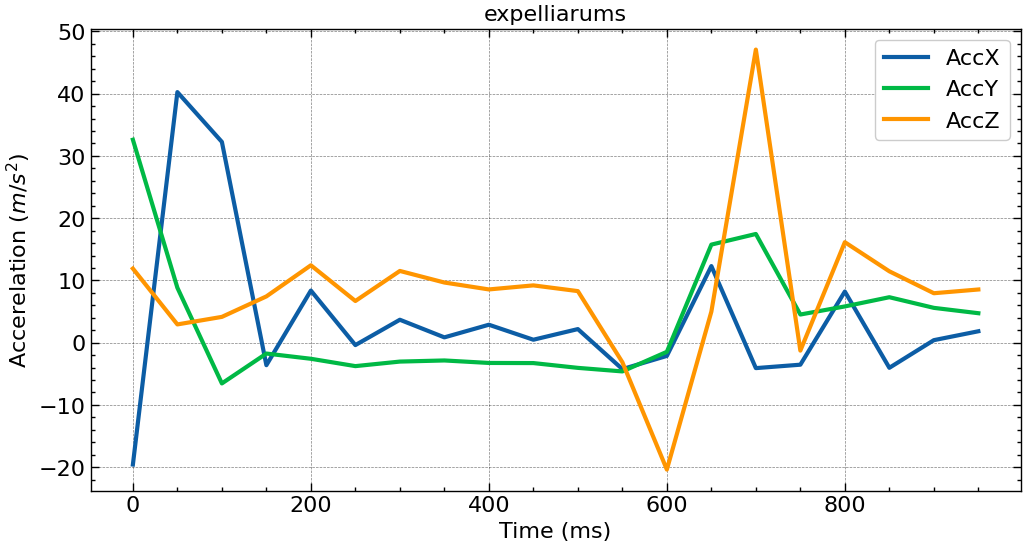

In [7]:
# Plotting a sample of data for visualisation
PLOT_IDX = 124
# Plot settings 
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['lines.linewidth'] = 3

plt.title(f"{labels[PLOT_IDX]}")
plt.plot(timesteps, data[PLOT_IDX])
plt.xlabel("Time (ms)")
plt.ylabel("Accerelation $(m/s^2)$")
plt.legend(['AccX', 'AccY', 'AccZ'])

#### Generating the data

This model use Iss2Image preprocessing technique. Iss2Image is a feature extraction technique that converts time-series sensor data (like accelerometer readings) into image-like representations for machine learning. It takes multi-axis sensor data, normalizes each axis to 0-255 range, then decomposes each normalized value into RGB color components using mathematical operations. The integer part becomes the R channel, the first decimal becomes G, and the second decimal becomes B. This creates a 3D array where each time sample maps to RGB pixel values. The resulting "image" can then be processed by convolutional neural networks, enabling the use of computer vision techniques on sensor data for applications like activity recognition or motion classification.Retry

In [8]:
# Iss2Image
def extract_features(data):
   
   # Separating the x, y, and z axis
   x_axis = data[:,0]
   y_axis = data[:,1]
   z_axis = data[:,2]
   
   # Normalising the data to fit in the width of 255
   x_norm = (x_axis - np.min(x_axis))/(np.max(x_axis) - np.min(x_axis)) * 255
   y_norm = (y_axis - np.min(y_axis))/(np.max(y_axis) - np.min(y_axis)) * 255
   z_norm = (z_axis - np.min(z_axis))/(np.max(z_axis) - np.min(z_axis)) * 255

   # Converting the accelerometer data into R, G, B values
    
   r_x = np.floor(x_norm)
   g_x = np.floor((x_norm - r_x) * 10**2)
   b_x = np.floor((x_norm*10**2 - np.floor(x_norm * 10**2))*10**2)
   
   r_y = np.floor(y_norm)
   g_y = np.floor((y_norm - r_y) * 10**2)
   b_y = np.floor((y_norm*10**2 - np.floor(y_norm * 10**2))*10**2)

   r_z = np.floor(z_norm)
   g_z = np.floor((z_norm - r_z) * 10**2)
   b_z = np.floor((z_norm*10**2 - np.floor(z_norm * 10**2))*10**2)
   
   R = np.ndarray((20,3), dtype=np.int8)
   G = np.ndarray((20,3), dtype=np.int8)
   B = np.ndarray((20,3), dtype=np.int8)
   R = np.stack([r_x, r_y, r_z], axis = 1)
   G = np.stack([g_x, g_y, g_z],  axis = 1)
   B = np.stack([b_x, b_y, b_z],  axis = 1)
    
   return np.stack((R, G, B)).reshape(20, 3, 3) # Returning the final features array

In [16]:
features = np.ndarray((TOTAL_DATA_SAMPLES, NUM_DATA_SAMPLES, NUM_DATA_COLS, 3), dtype=np.int16)
for i in range(features.shape[0]):
   features[i] = extract_features(data[i])

#### Plotting the features

Text(0.5, 1.0, 'reparo_793.csv')

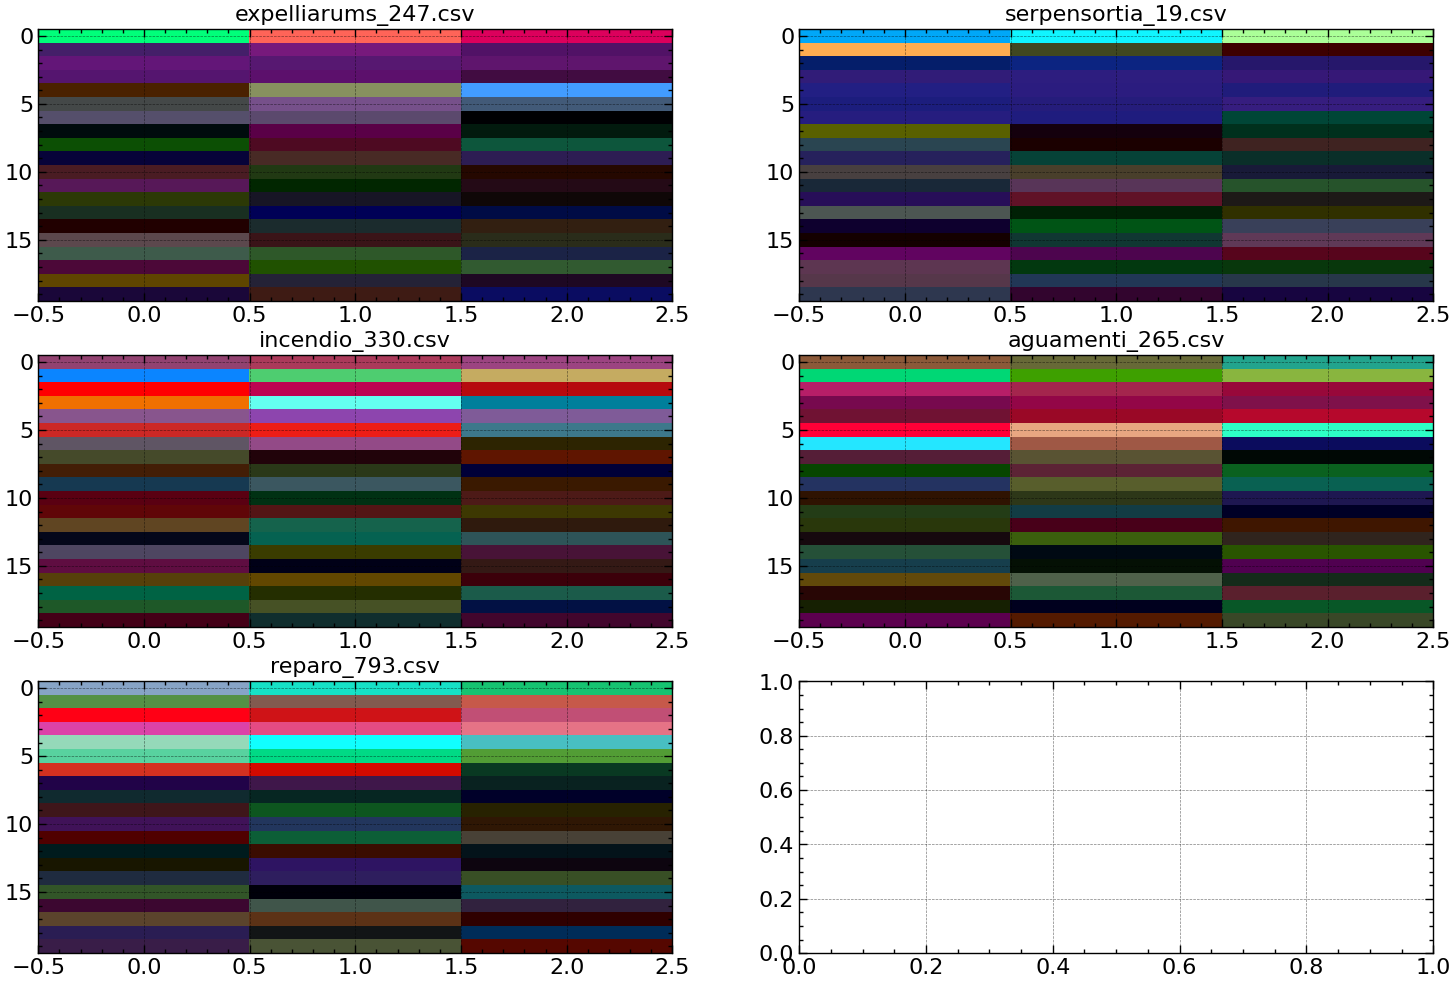

In [17]:
fig, ((ax1, ax2), (ax3, ax4), (ax5,ax6)) = plt.subplots(nrows=3, ncols=2)

fig.set_size_inches(18,12)
ax1.imshow(features[PLOT_IDX], aspect='auto')
ax1.set_title(f"{filenames[PLOT_IDX]}")

ax2.imshow(features[210], aspect='auto')
ax2.set_title(f"{filenames[210]}")

ax3.imshow(features[450], aspect='auto')
ax3.set_title(f"{filenames[450]}")

ax4.imshow(features[600], aspect='auto')
ax4.set_title(f"{filenames[600]}")

ax5.imshow(features[360], aspect='auto')
ax5.set_title(f"{filenames[360]}")

#### Developing the model

In [18]:
# Model setting
data_input_shape = features.shape
num_gestures = 5
TEST_SIZE = 0.3
TRAIN_SIZE = 0.7

### Creating the y_labels array
AGUAMENTI_IDX = 0
EXPELLIARUMS_IDX = 1
INCENDIO_IDX = 2
REPARO_IDX = 3
SERPENSORTIA_IDX = 4

ENABLE = 1
i = 0
y_labels = np.zeros([616, 5])
for label in labels:
   if label == "aguamenti":
      y_labels[i][AGUAMENTI_IDX] = ENABLE
   if label == "expelliarums":
      y_labels[i][EXPELLIARUMS_IDX] = ENABLE
   if label == "incendio":
      y_labels[i][INCENDIO_IDX] = ENABLE
   if label == "reparo":
      y_labels[i][REPARO_IDX] = ENABLE
   if label == "serpensortia":
      y_labels[i][SERPENSORTIA_IDX] = ENABLE
   i += 1

In [25]:
# Separating x and y data into training, testing and validation sets
x_data = features  
y_labels = np.array(y_labels)
x_shuffled, y_shuffled = shuffle(x_data, y_labels, random_state=42)
x_train, x_test, y_train, y_test = train_test_split(x_shuffled, y_shuffled, test_size=TEST_SIZE, random_state=48)
x_test, x_val, y_test, y_val = train_test_split(x_test, y_test, test_size=0.125, random_state=42)
print(x_train.shape, x_test.shape, y_test.shape, y_train.shape, x_val.shape, y_val.shape)

(431, 20, 3, 3) (161, 20, 3, 3) (161, 5) (431, 5) (24, 20, 3, 3) (24, 5)


In [65]:
### This function creates the CNN model used for this project

def create_cnn_model(input_shape=(20, 3, 3)):
   model = Sequential([ 
      Input(input_shape),
      Conv2D(8, 2, padding='same', activation='relu'),
      Conv2D(16, 2, padding='same', activation='relu'),
      Conv2D(32, 2, padding='same', activation='relu'),
      GlobalAveragePooling2D(), 
      Dense(32, activation="relu"),
      Dense(16, activation="relu"),
      Dense(5, name='y_pred', activation='softmax')
   ])
      
   model.compile(
      loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
   return model

In [66]:
model = create_cnn_model()
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_17 (Conv2D)              │ (None, 20, 3, 8)       │           104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 20, 3, 16)      │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 20, 3, 32)      │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_6      │ (None, 32)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ y_pred (Dense)                  │ (None, 5)              │            85 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,381 (17.11 KB)

 Trainable params: 4,381 (17.11 KB)

 Non-trainable params: 0 (0.00 B)

In [59]:
# Training the model
history = model.fit(
   x_train, y_train,
   epochs = 500,
   batch_size = 32,
   validation_data=(x_val, y_val),
   verbose = 1
)

Epoch 1/500
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.1972 - loss: 4.1198 - val_accuracy: 0.3333 - val_loss: 2.0745
Epoch 2/500
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2204 - loss: 1.9372 - val_accuracy: 0.2083 - val_loss: 1.4999
Epoch 3/500
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2831 - loss: 1.6544 - val_accuracy: 0.4583 - val_loss: 1.3426
Epoch 4/500
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2877 - loss: 1.5300 - val_accuracy: 0.5833 - val_loss: 1.2555
Epoch 5/500
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3875 - loss: 1.4957 - val_accuracy: 0.4583 - val_loss: 1.2003
Epoch 6/500
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3480 - loss: 1.4899 - val_accuracy: 0.7083 - val_loss: 1.1224
Epoch 7/500
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3991 - loss: 1.3867 - val_accuracy: 0.6250 - val_loss: 1.0972
Epoch 8/500
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4478 - loss: 1.3521 - val_accuracy: 0.5417 - 

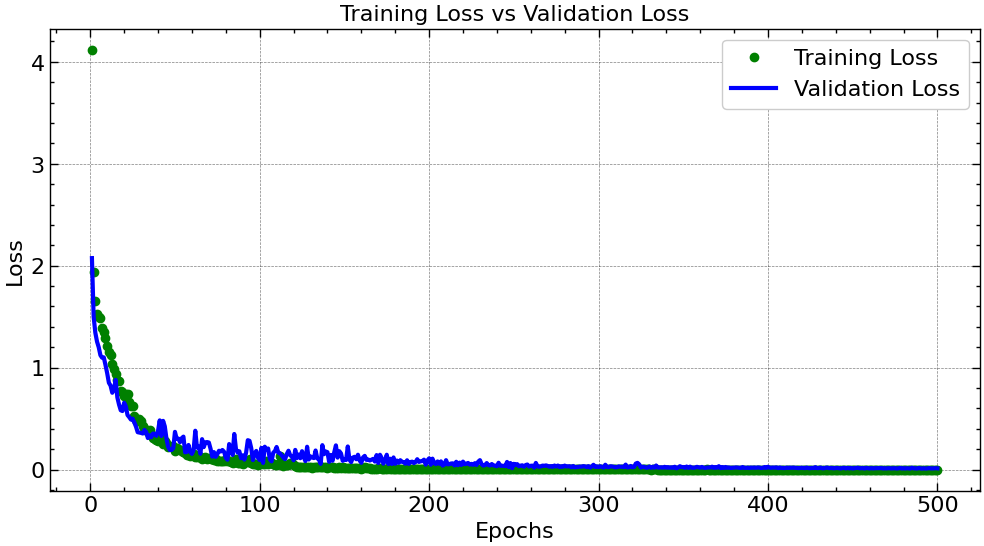

In [60]:
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, "go", label="Training Loss")
plt.plot(epochs, val_loss, "b", label="Validation Loss")
plt.title("Training Loss vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

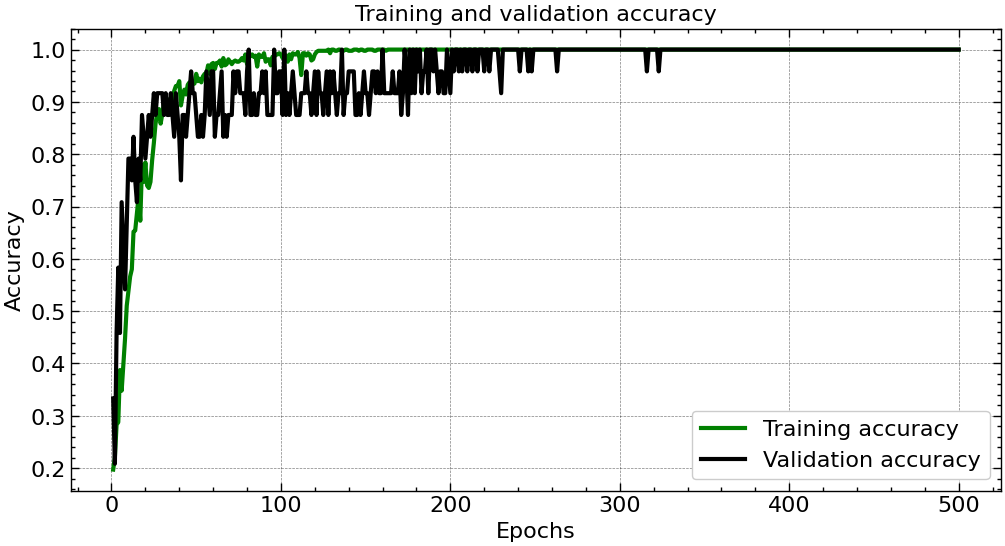

Final Training Accuracy: 1.0
Final Validation Accuracy: 1.0


In [61]:
plt.clf()
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
plt.plot(epochs, acc, "g-", label="Training accuracy")
plt.plot(epochs, val_acc, "black", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


final_train_acc = history.history['accuracy'][-1]
final_val_acc   = history.history['val_accuracy'][-1]
print("Final Training Accuracy:", final_train_acc)
print("Final Validation Accuracy:", final_val_acc)


In [62]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print("Test Accuracy:", test_acc, "Test Loss:", test_loss)

Test Accuracy: 0.9378882050514221 Test Loss: 0.2595447897911072


## Deploying The Model

### Generating a TfLite Micro Model

In [45]:
import tensorflow as tf

# Model Settings
SAVED_MODEL_FILENAME          = "magic_wand_quant.keras"
SAVED_MODEL_FILENAME_NO_QUANT = "magic_wand_float.keras"
QUANTIZED_TFL_MODEL_FILENAME = "magic_wand_quant.tflite"
model.save(SAVED_MODEL_FILENAME_NO_QUANT)


In [46]:
# Loading the saved model
modelKeras = tf.keras.models.load_model(SAVED_MODEL_FILENAME_NO_QUANT)

# Convert the Keras model to a TfLite Micro
converter = tf.lite.TFLiteConverter.from_keras_model(modelKeras)
model_no_quant = converter.convert()

# Saving the converted model
open(f"{SAVED_MODEL_FILENAME_NO_QUANT}", "wb").write(model_no_quant)

/Users/owaistalpur/Desktop/Embedded/magic_wand_project/.venv/lib/python3.13/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 14 variables whereas the saved optimizer has 26 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


INFO:tensorflow:Assets written to: /var/folders/vg/44zklqr15qvd1xsn9ngfjzvm0000gn/T/tmpse_fep5j/assets


INFO:tensorflow:Assets written to: /var/folders/vg/44zklqr15qvd1xsn9ngfjzvm0000gn/T/tmpse_fep5j/assets


Saved artifact at '/var/folders/vg/44zklqr15qvd1xsn9ngfjzvm0000gn/T/tmpse_fep5j'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 20, 3, 3), dtype=tf.float32, name='input_layer_2')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  6003022672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5973113360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6003469456: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6003470032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6003468112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6003261264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6003245904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6003256848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6003257040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6003256464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6003256656: TensorSpec

W0000 00:00:1756895715.506817  417942 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1756895715.506831  417942 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
2025-09-03 20:35:15.506956: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/vg/44zklqr15qvd1xsn9ngfjzvm0000gn/T/tmpse_fep5j
2025-09-03 20:35:15.507386: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2025-09-03 20:35:15.507392: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /var/folders/vg/44zklqr15qvd1xsn9ngfjzvm0000gn/T/tmpse_fep5j
2025-09-03 20:35:15.512609: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2025-09-03 20:35:15.535225: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bundle at path: /var/folders/vg/44zklqr15qvd1xsn9ngfjzvm0000gn/T/tmpse_fep5j
2025-09-03 20:35:15.543308: I tensorflow/cc/saved_model/loader.cc:

21368

In [47]:
# Creating a Quantised Model

def representative_dataset():
  for data in tf.data.Dataset.from_tensor_slices((features)).batch(1).take(100):
    yield [tf.dtypes.cast(data, tf.float32)]

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

model_quant = converter.convert()
with open(f"{QUANTIZED_TFL_MODEL_FILENAME}", "wb") as f:
    f.write(model_quant)

INFO:tensorflow:Assets written to: /var/folders/vg/44zklqr15qvd1xsn9ngfjzvm0000gn/T/tmpixmz44_d/assets


INFO:tensorflow:Assets written to: /var/folders/vg/44zklqr15qvd1xsn9ngfjzvm0000gn/T/tmpixmz44_d/assets


Saved artifact at '/var/folders/vg/44zklqr15qvd1xsn9ngfjzvm0000gn/T/tmpixmz44_d'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 20, 3, 3), dtype=tf.float32, name='keras_tensor_16')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  6003468688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6003472720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6003472528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6003472912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6003473104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6003469072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6003473296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6003470608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6003470416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6003470800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6003471184: TensorSp

/Users/owaistalpur/Desktop/Embedded/magic_wand_project/.venv/lib/python3.13/site-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
W0000 00:00:1756895717.479134  417942 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1756895717.479143  417942 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
2025-09-03 20:35:17.479242: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/vg/44zklqr15qvd1xsn9ngfjzvm0000gn/T/tmpixmz44_d
2025-09-03 20:35:17.479842: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2025-09-03 20:35:17.479847: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /var/folders/vg/44zklqr15qvd1xsn9ngfjzvm0000gn/T/tmpixmz44_d
2025-09-03 20:35:17.483770: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2025-09-03

In [48]:
size_no_quant_tflite = os.path.getsize(SAVED_MODEL_FILENAME_NO_QUANT)
size_tflite = os.path.getsize(f"{QUANTIZED_TFL_MODEL_FILENAME}")

print(size_no_quant_tflite, size_tflite)

21368 11632


#### Testing the TfLite Micro Model

In [49]:
import keras

#  Initialize the TFLite interpreter
interpreter = tf.lite.Interpreter(model_content=model_no_quant)
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()[0]
output_details = interpreter.get_output_details()[0]

for i in range(3):
   # Debug: Check expected input shape
   data = x_test[i].reshape((1, 20, 3, 3))
   # For tabular data, use the array directly
   input_data = data.astype(np.float32)  # Ensure correct dtype
   # Set tensor and run inference
   interpreter.set_tensor(input_details["index"], input_data)
   interpreter.invoke()
   pred = interpreter.get_tensor(output_details["index"])[0]

   predicted_label_index = np.argmax(pred)
   predicted_score = pred[predicted_label_index]

   print("Test: ")
   print(np.round(pred, 2), "\n\n", "Predicted Label: \n", predicted_label_index+ 1, predicted_score, "\n\nActual: \n", "expelliarums")  
   print("\n ================== \n")

Test: 
[1. 0. 0. 0. 0.] 

 Predicted Label: 
 1 0.99999976 

Actual: 
 expelliarums


Test: 
[0. 0. 0. 1. 0.] 

 Predicted Label: 
 4 1.0 

Actual: 
 expelliarums


Test: 
[0. 0. 0. 0. 1.] 

 Predicted Label: 
 5 0.9999999 

Actual: 
 expelliarums




/Users/owaistalpur/Desktop/Embedded/magic_wand_project/.venv/lib/python3.13/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [ ]:
TFL_CC_MODEL_FILENAME = "~/Desktop/Embedded/magic_wand/lib/magic_wand_model/magic_wand_model.cc"
# Convert to a C source file, i.e, a TensorFlow Lite for Microcontrollers model
!xxd -i {QUANTIZED_TFL_MODEL_FILENAME} > {TFL_CC_MODEL_FILENAME}